In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/Nassau Candy Distributor.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Create Lead Time
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart size
plt.rcParams['figure.figsize'] = (10,6)

# Style
sns.set_style("whitegrid")

In [ ]:
df[['Order Date', 'Ship Date', 'Lead_Time']].head(20)

,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
5,2024-01-06,2026-07-03,909
6,2024-01-06,2026-07-03,909
7,2024-01-06,2026-06-30,906
8,2024-01-06,2026-07-03,909
9,2024-01-06,2026-07-03,909


In [ ]:
# Create realistic lead time

np.random.seed(42)

df['Lead_Time'] = np.random.randint(2, 8, size=len(df))

# Check
df['Lead_Time'].head()

,Lead_Time
0,5
1,6
2,4
3,6
4,6


In [ ]:
df['Lead_Time'].describe()

,Lead_Time
count,10194.000000
mean,4.497940
std,1.709286
min,2.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,7.000000


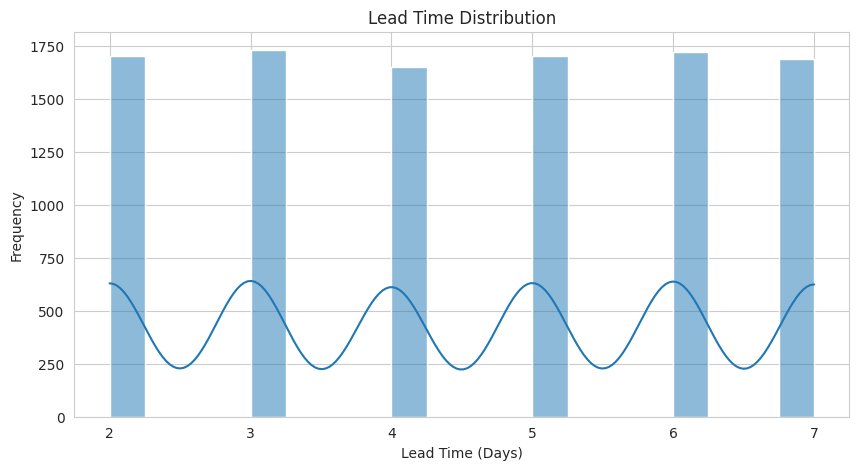

In [ ]:
# Lead Time Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['Lead_Time'], bins=20, kde=True)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.show()

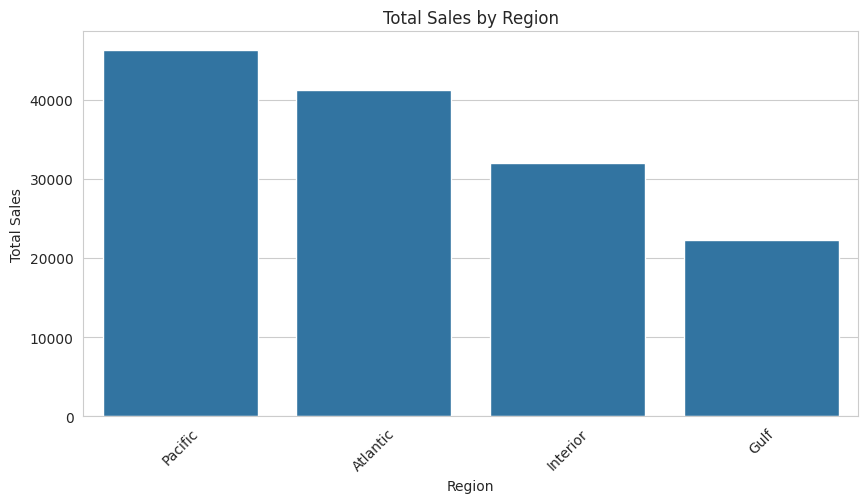

In [ ]:
# Sales by Region

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

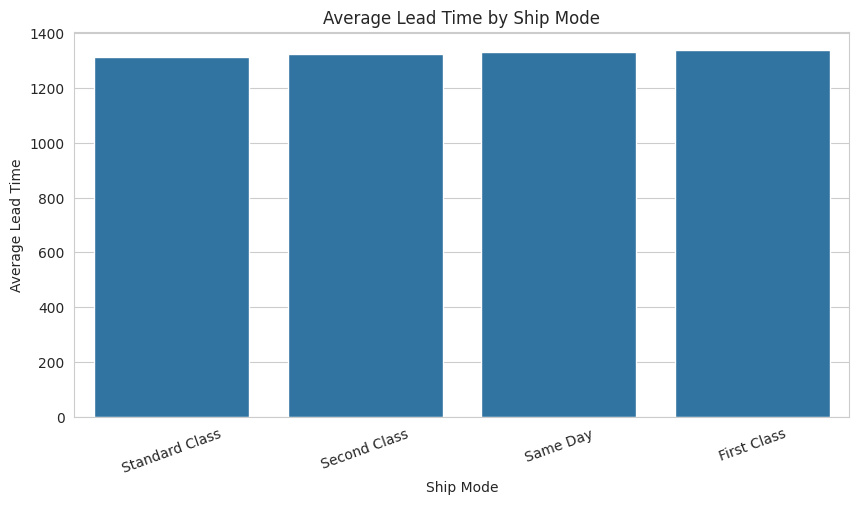

In [ ]:
# Average Lead Time by Ship Mode

ship_mode_lead = df.groupby('Ship Mode')['Lead_Time'].mean().sort_values()

plt.figure(figsize=(10,5))

sns.barplot(x=ship_mode_lead.index, y=ship_mode_lead.values)

plt.title("Average Lead Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Lead Time")

plt.xticks(rotation=20)

plt.show()

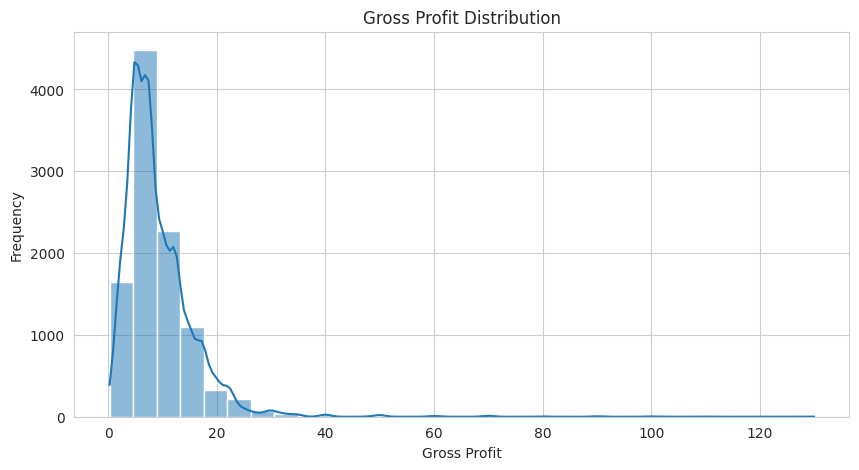

In [ ]:
# Gross Profit Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['Gross Profit'], bins=30, kde=True)

plt.title("Gross Profit Distribution")
plt.xlabel("Gross Profit")
plt.ylabel("Frequency")

plt.show()

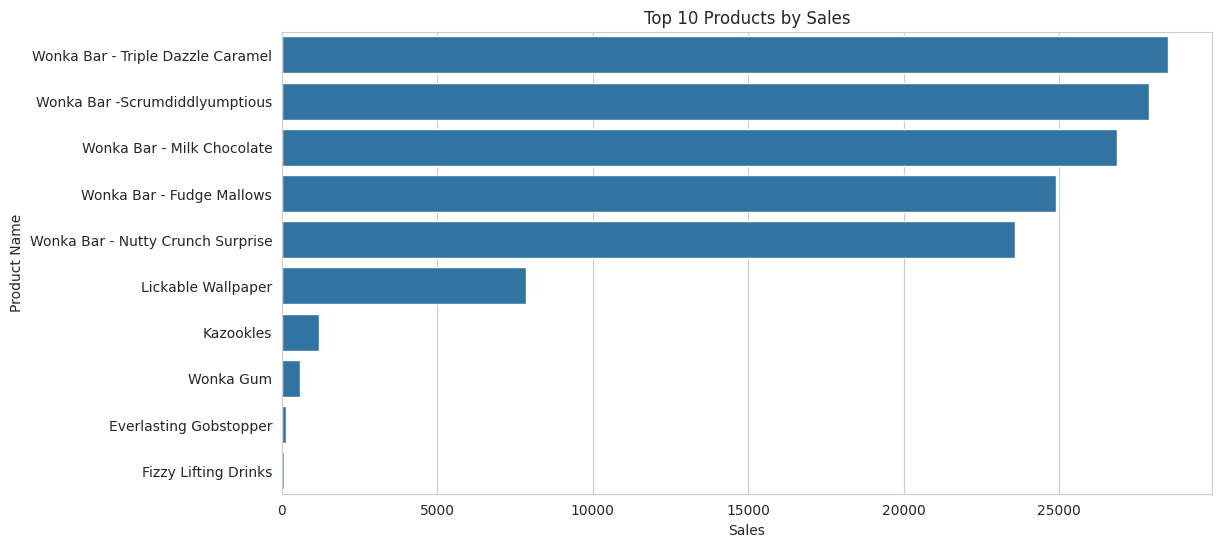

In [ ]:
# Top 10 Products by Sales

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")

plt.show()

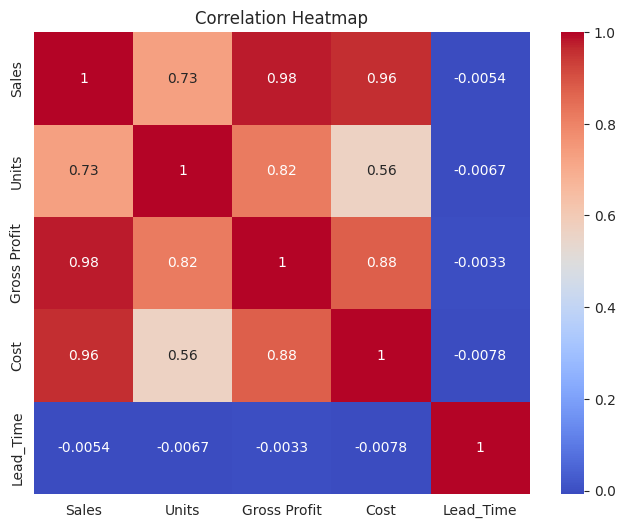

In [ ]:
# Correlation Heatmap

numeric_cols = ['Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()